In [1]:
import os
print(os.getcwd())          # shows current working directory
print(os.listdir("../data"))   # lists files inside data folder

C:\Users\nushr\house-price-ml-pipeline\notebooks
['.gitkeep.txt', '.ipynb_checkpoints', 'cleaned_housing.csv', 'feature_engineered_housing.csv', 'final_prepared.csv', 'housing.csv', 'Untitled.ipynb', 'Untitled1.ipynb']


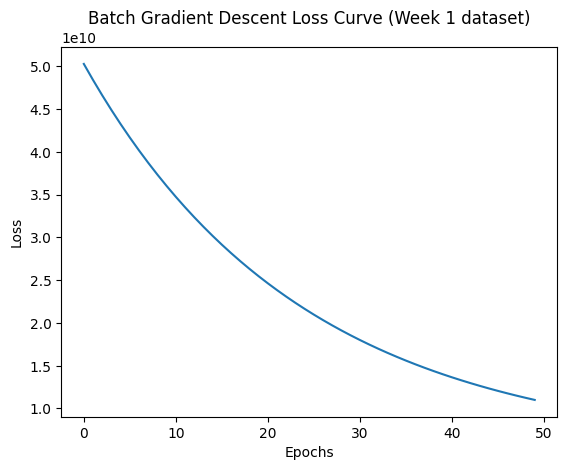

In [2]:
import sys
sys.path.append("..")   # makes src visible

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.optimizers import OptimizerEngine

# Load Week 1 dataset
df = pd.read_csv("../data/final_prepared.csv")

X = df.drop(columns=["median_house_value"]).values
y = df["median_house_value"].values

# Initialize weights and optimizer
w = np.zeros(X.shape[1])
b = 0
optimizer = OptimizerEngine(optimizer_type="batch", learning_rate=0.01, epochs=50)

losses = []
for epoch in range(optimizer.epochs):
    y_pred = X.dot(w) + b
    grad_w = (2/X.shape[0]) * X.T.dot(y_pred - y)
    grad_b = (2/X.shape[0]) * np.sum(y_pred - y)

    w = optimizer.update_params(w, grad_w, epoch)
    b = b - optimizer.lr * grad_b

    loss = np.mean((y - y_pred)**2)
    losses.append(loss)

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Batch Gradient Descent Loss Curve (Week 1 dataset)")
plt.show()

In [3]:
import os
os.makedirs("../results", exist_ok=True)
np.save("../results/batch_loss.npy", losses)


In [4]:
import os
print(os.listdir("../results"))


['adam_loss.npy', 'batch_loss.npy', 'minibatch_loss.npy', 'momentum_loss_beta_09.npy', 'momentum_loss_beta_095.npy', 'rmsprop_loss.npy', 'sgd_loss.npy', 'week3_comparision.csv', 'week3_comparison.csv']
